# Print Geometries

## 1. Introduction
Script to print geometries using graphs.

Useful for testing points generated from different geometries. With this script we can make sure that a Point is inside the original geometry.

## 2. Libraries

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely import wkt

## 3. Setup
Here we define the 2 geometries (A and B). Use WKT (well-know text).

You can also define the colours for A and B.

In [13]:
A = 'MULTIPOLYGON(((-0.1890 38.9710, -0.1790 38.9710, -0.1790 38.9640, -0.1890 38.9640, -0.1890 38.9710)),((-0.1645 38.9950, -0.1555 38.9950, -0.1555 38.9850, -0.1645 38.9850, -0.1645 38.9950)))'
B = 'POINT (-0.184 38.9675)'

COLOR_MAP = {"A": "red", "B": "blue"}

## 4. Internal methods

In [ ]:
def setDataFrame() -> pd.DataFrame:
  df = pd.DataFrame({
    'name': ['A', 'B'],
    'geom_wkt': [A, B]
  })

  return df


def convertWKTtoGeoDataFrame(df: pd.DataFrame) -> gpd.GeoDataFrame:
  df["geometry"] = df["geom_wkt"].apply(wkt.loads)  
  return gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")



def printGeometries(gdf: gpd.GeoDataFrame) -> None:
  gdf["color"] = gdf["name"].map(COLOR_MAP)
  gdf_A = gdf[gdf["name"] == "A"]
  gdf_B = gdf[gdf["name"] == "B"]
  ax = gdf_A.plot(color="red", figsize=(5, 5), zorder=1)
  gdf_B.plot(ax=ax, color="blue", zorder=2)  # on top
  plt.show()  


## 5. Main

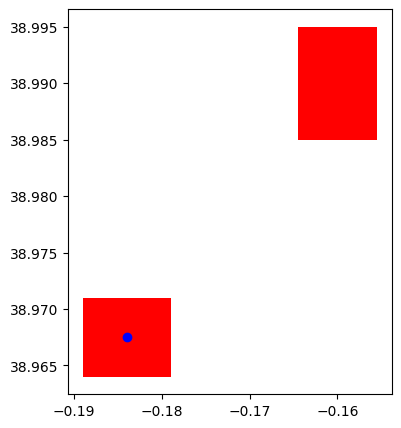

In [15]:
df = setDataFrame()
gdf = convertWKTtoGeoDataFrame(df)
printGeometries(gdf)  